In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import networkx as nx
import os 

**1.Chargement des fichiers**

In [2]:
# Charger les données du premier réseau
data = pd.read_csv('data_train/data1.csv')
target = pd.read_csv('data_train/target1.csv')
data.head(), target.head()

(         V0        V1        V2        V3        V4        V5        V6  \
 0 -0.274018 -1.609865 -0.546092 -0.762529 -0.738399       NaN -1.179910   
 1 -1.445791  0.800972 -1.300660 -1.179378 -1.289348  0.381551 -0.834005   
 2  0.040794 -0.304655  0.138629  0.066356 -0.419415 -0.530303 -0.639287   
 3  1.750802  0.151451  1.703113  1.682361  0.910788  0.221794  1.412876   
 4 -0.898138  0.234620 -1.057411 -0.935669 -0.832055 -0.127360 -0.998315   
 
          V7        V8        V9       V10       V11       V12       V13  \
 0 -1.068921 -1.184767  0.057903 -0.755056 -0.442939 -1.676398 -1.287949   
 1 -0.425970       NaN       NaN -1.683891 -0.692397  0.357126 -0.611319   
 2 -0.426780 -0.180585 -0.672954 -0.503293 -0.243091 -0.033607 -0.296831   
 3       NaN  1.544998  2.066780 -0.832776  1.713802       NaN  1.424940   
 4 -0.905834 -0.674983       NaN -2.127721 -1.208617  1.609004       NaN   
 
         V14       V15       V16       V17       V18       V19  
 0 -1.180937 -1.372

**3. Statistiques de base sur le réseau**

Nous allons afficher le nombre de variables, de liens directs et de points d'observation pour le premier réseau.

In [3]:
# Nombre de variables, de points d'observation et de liens directs
d = data.shape[1]
n_points = data.shape[0]
n_liens = target.shape[0]

print(f"Nombre de variables (d): {d}")
print(f"Nombre de points d'observation: {n_points}")
print(f"Nombre de liens directs: {n_liens}")

Nombre de variables (d): 20
Nombre de points d'observation: 500
Nombre de liens directs: 46


**4. Imputation aléatoire des valeurs manquantes**

On remplace chaque valeur manquante d'une variable par une valeur tirée aléatoirement parmi les valeurs non manquantes de cette même variable.

In [4]:
def impute_missing_random(df):
    for col in df.columns:
        mask = df[col].isna()
        if mask.any():
            values = df.loc[~mask, col]
            df.loc[mask, col] = np.random.choice(values, size=mask.sum(), replace=True)
    return df

data_imputed = impute_missing_random(data.copy())
data_imputed.head()

,V0,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19
0,-0.274018,-1.609865,-0.546092,-0.762529,-0.738399,-0.004132,-1.179910,-1.068921,-1.184767,0.057903,-0.755056,-0.442939,-1.676398,-1.287949,-1.180937,-1.372720,-0.960208,-1.523203,-1.333317,-0.628882
1,-1.445791,0.800972,-1.300660,-1.179378,-1.289348,0.381551,-0.834005,-0.425970,-1.843222,-0.635708,-1.683891,-0.692397,0.357126,-0.611319,-1.544684,-1.263291,-1.445179,-0.946510,-1.439712,-0.321130
2,0.040794,-0.304655,0.138629,0.066356,-0.419415,-0.530303,-0.639287,-0.426780,-0.180585,-0.672954,-0.503293,-0.243091,-0.033607,-0.296831,-0.698863,-0.891388,-0.740804,-0.930931,-0.746842,-0.740830
3,1.750802,0.151451,1.703113,1.682361,0.910788,0.221794,1.412876,0.459923,1.544998,2.066780,-0.832776,1.713802,-0.086274,1.424940,1.263261,0.382586,0.654751,0.568670,1.238103,1.670034
4,-0.898138,0.234620,-1.057411,-0.935669,-0.832055,-0.127360,-0.998315,-0.905834,-0.674983,0.226047,-2.127721,-1.208617,1.609004,-2.380972,-1.245270,-1.800076,-1.259535,-1.014337,-1.518317,-1.787845


**5. Normalisation des données**


On normalise les données pour que chaque variable ait une moyenne nulle et un écart-type de 1.

In [5]:
scaler = StandardScaler()
data_normalized = pd.DataFrame(scaler.fit_transform(data_imputed), columns=data.columns)
data_normalized.head()

,V0,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19
0,-0.261051,-1.600076,-0.538153,-0.760092,-0.755617,0.015398,-1.177870,-1.068648,-1.191156,0.056155,-0.745314,-0.430863,-1.657818,-1.278151,-1.170654,-1.390587,-0.973457,-1.545060,-1.357861,-0.624428
1,-1.423922,0.773634,-1.294424,-1.172964,-1.305218,0.402052,-0.830304,-0.421798,-1.847149,-0.637001,-1.660638,-0.685749,0.338630,-0.598996,-1.538244,-1.281431,-1.458896,-0.961533,-1.464140,-0.317591
2,0.051370,-0.314967,0.148113,0.060886,-0.437414,-0.512096,-0.634651,-0.422613,-0.190728,-0.674223,-0.497213,-0.226666,-0.044979,-0.283335,-0.683487,-0.910455,-0.753841,-0.945769,-0.772028,-0.736042
3,1.748388,0.134116,1.716128,1.661475,0.889533,0.241893,1.427365,0.469467,1.528402,2.063716,-0.821904,1.772811,-0.096685,1.444862,1.299368,0.360345,0.643058,0.571603,1.210742,1.667651
4,-0.880429,0.216004,-1.050626,-0.931580,-0.849044,-0.108140,-0.995403,-0.904572,-0.683278,0.224189,-2.098011,-1.213203,1.567684,-2.375253,-1.235666,-1.816879,-1.273072,-1.030164,-1.542659,-1.779943


**6. Affichage des nuages de points pour chaque lien direct**

Pour chaque lien direct du réseau, on affiche le nuage de points (scatter plot) entre les deux variables concernées.

C:\Users\lassi\AppData\Local\Temp\ipykernel_4388\475818043.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  src, dst = row[0], row[1]


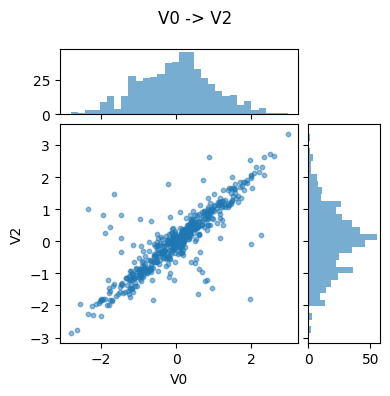

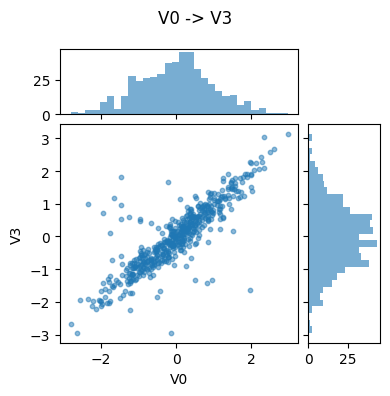

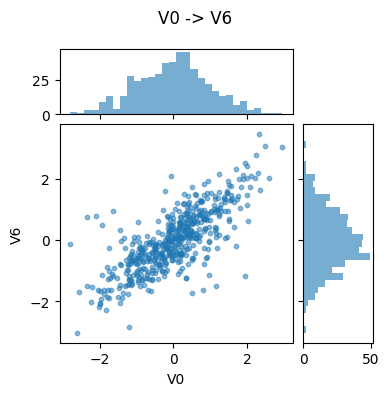

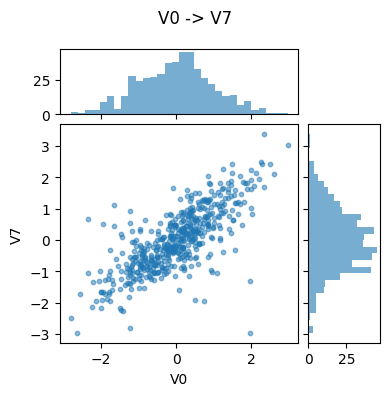

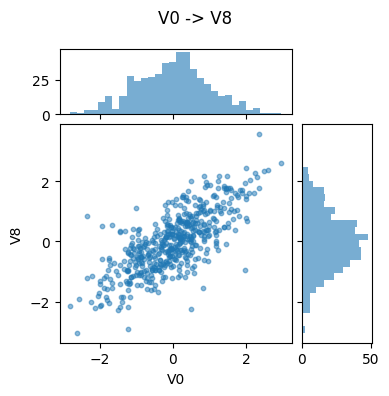

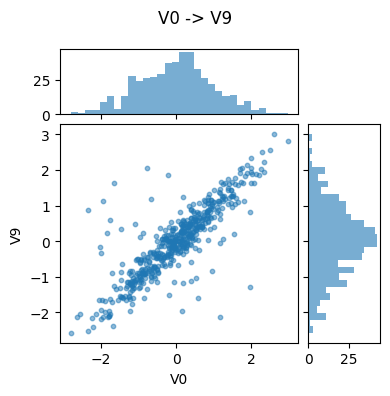

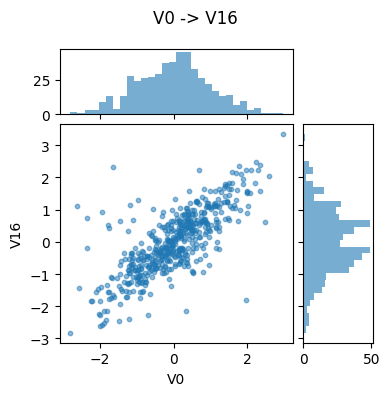

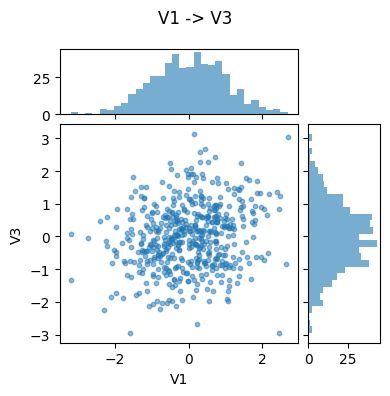

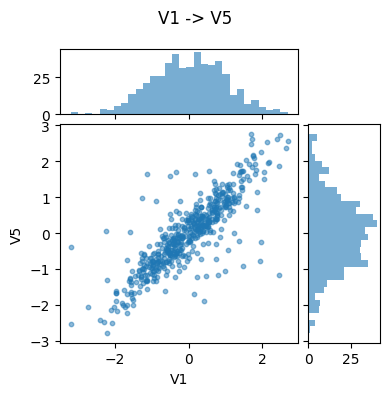

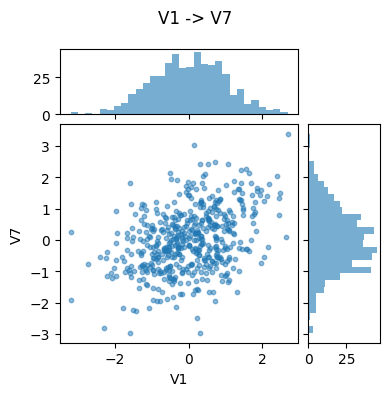

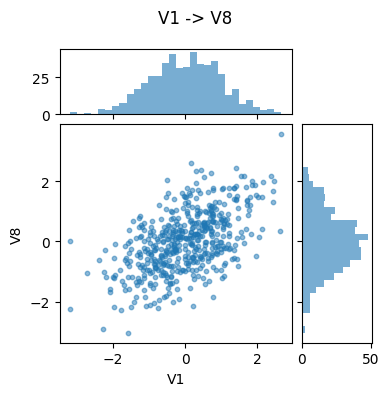

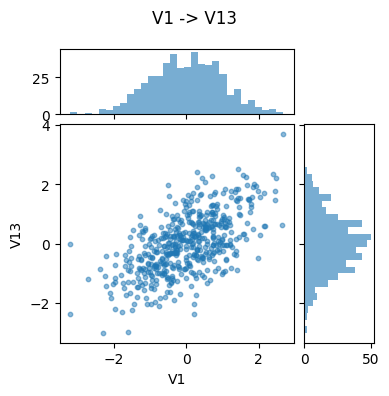

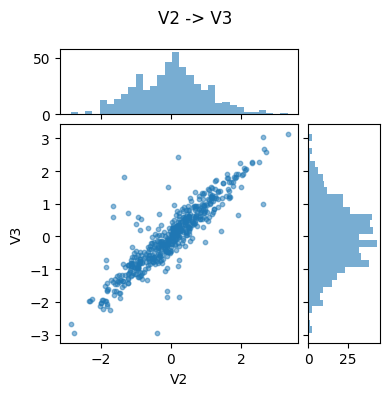

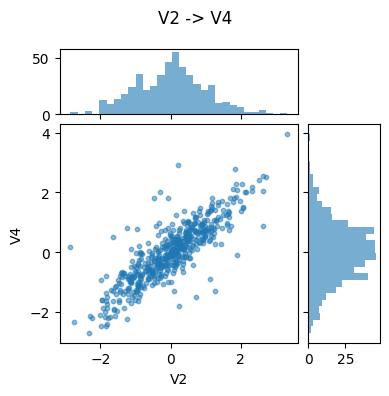

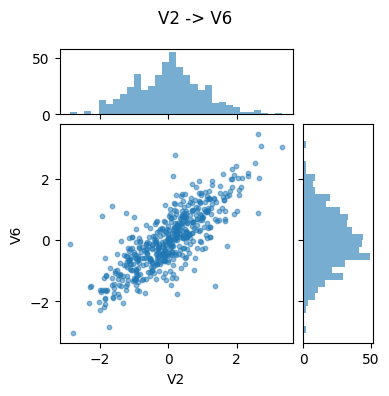

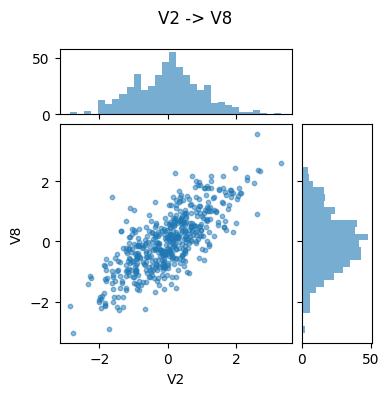

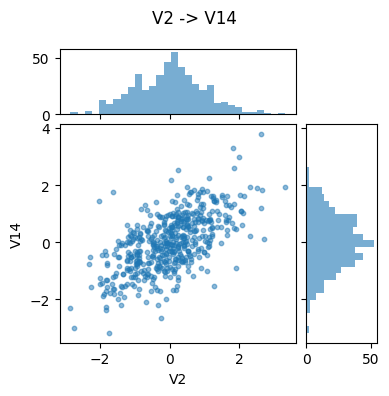

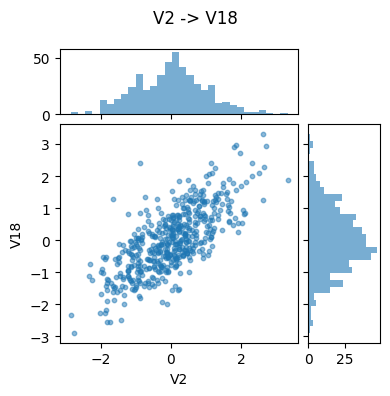

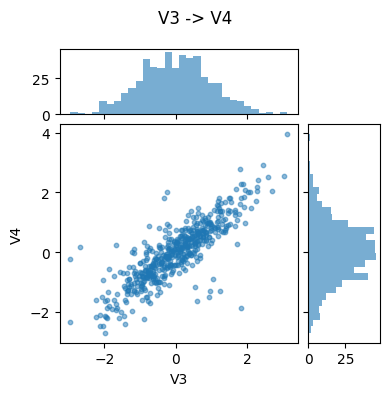

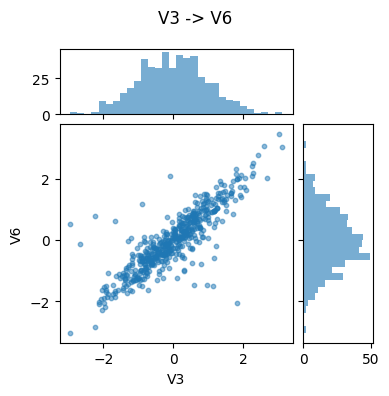

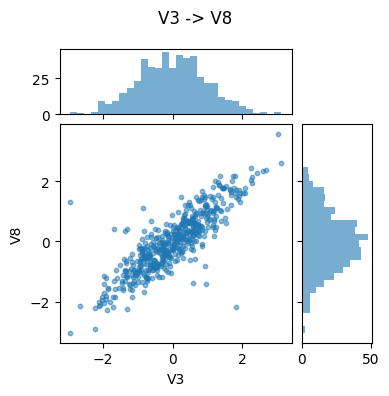

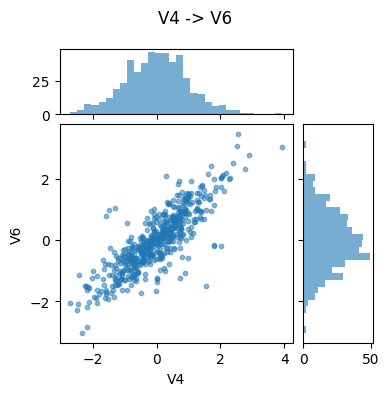

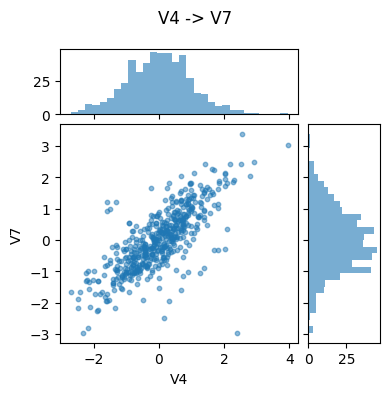

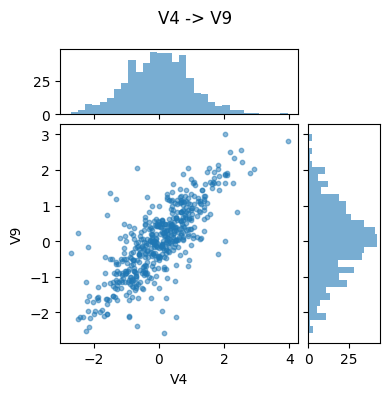

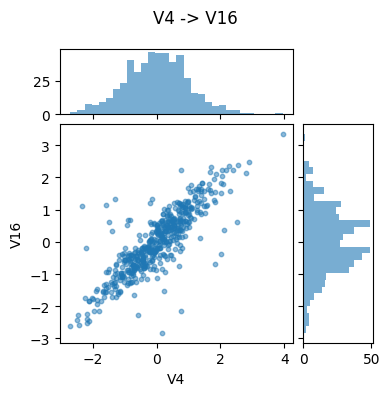

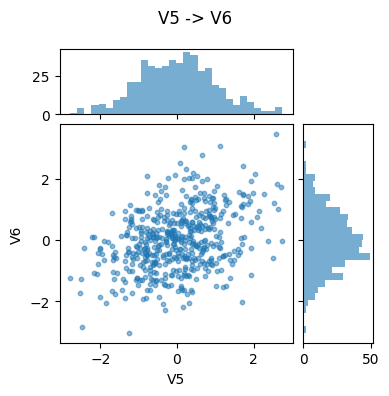

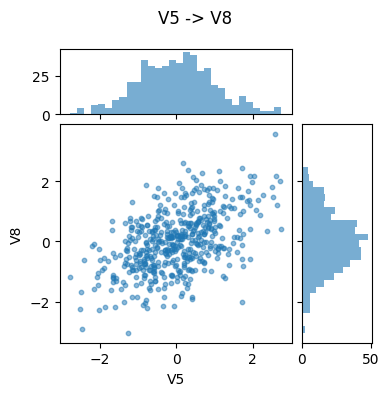

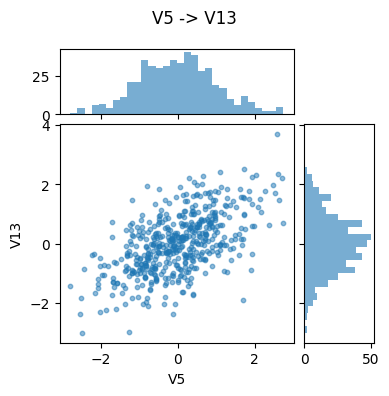

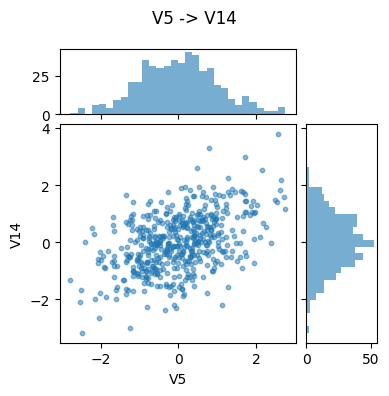

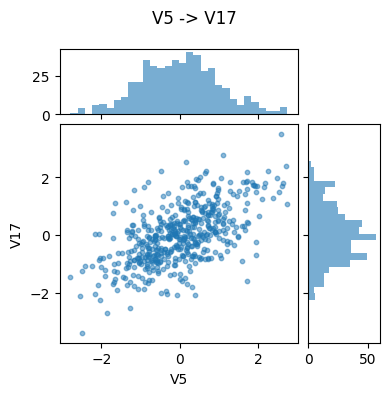

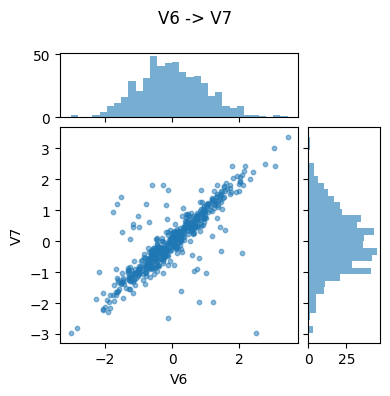

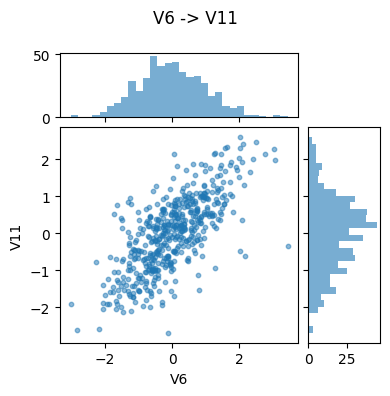

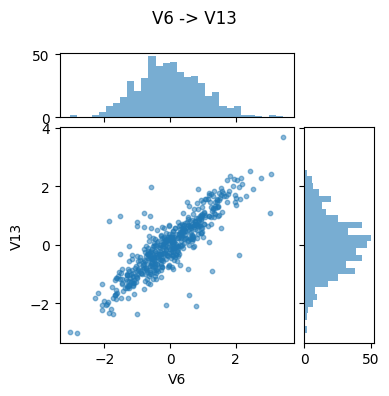

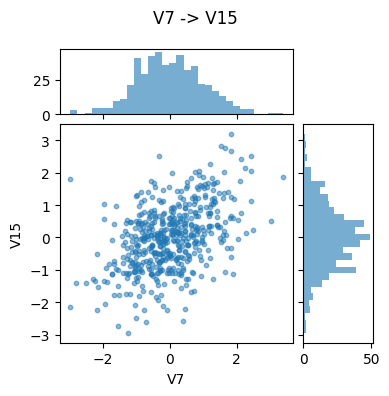

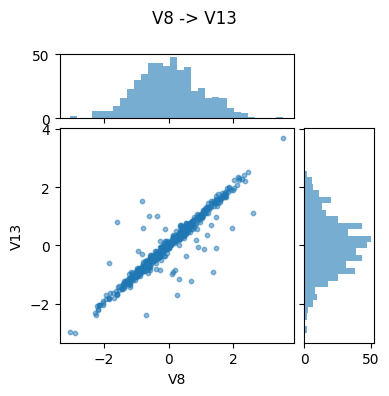

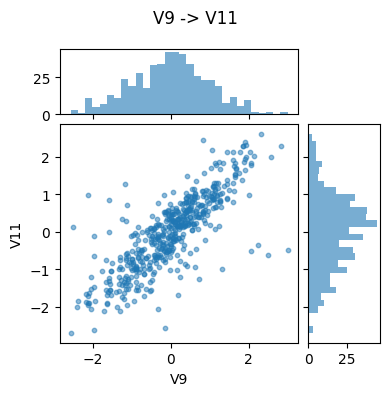

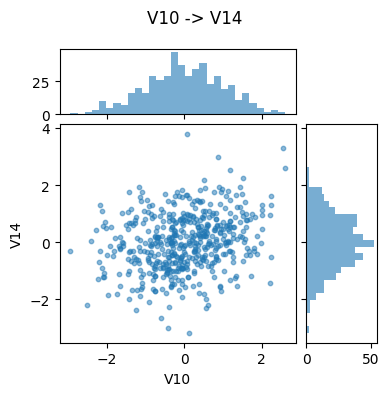

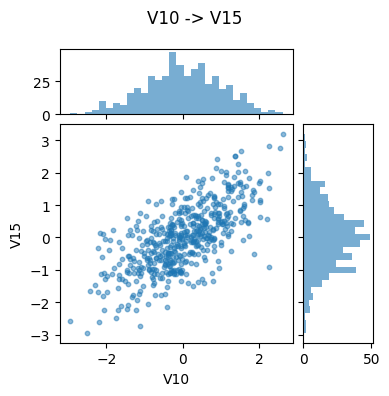

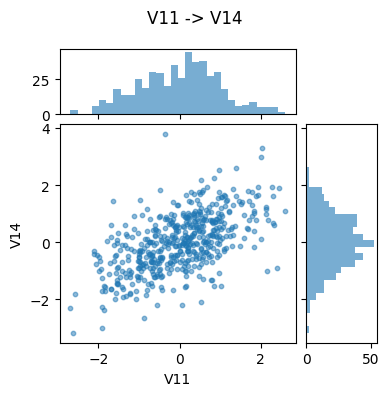

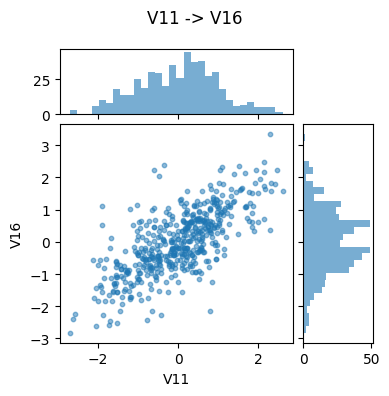

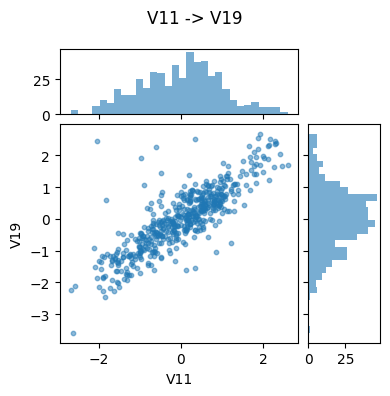

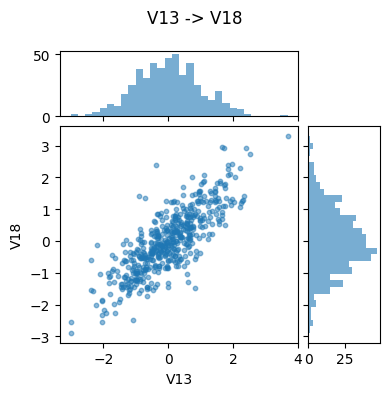

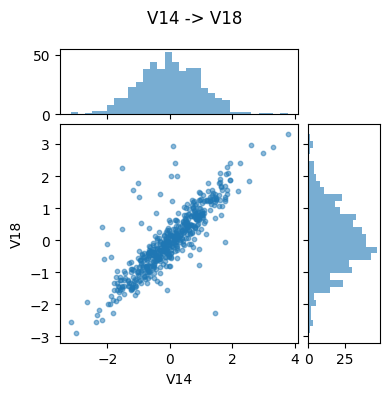

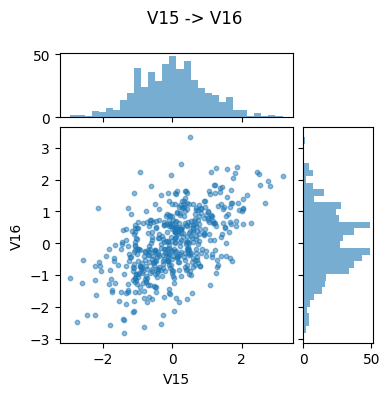

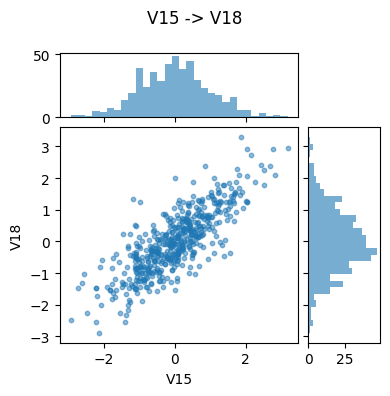

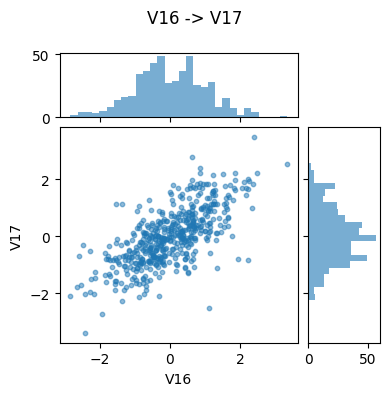

In [6]:
# Trace chaque lien dans une figure séparée avec histogrammes marginaux
from mpl_toolkits.axes_grid1 import make_axes_locatable
def plot_scatter_with_marginals(x, y, xlabel=None, ylabel=None, bins=30, figsize=(5,5)):
    fig, ax_scatter = plt.subplots(figsize=figsize)
    divider = make_axes_locatable(ax_scatter)
    ax_histx = divider.append_axes("top", size="30%", pad=0.1, sharex=ax_scatter)
    ax_histy = divider.append_axes("right", size="30%", pad=0.1, sharey=ax_scatter)
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_scatter.scatter(x, y, alpha=0.5, s=10)
    ax_histx.hist(x, bins=bins, color='C0', alpha=0.6)
    ax_histy.hist(y, bins=bins, orientation='horizontal', color='C0', alpha=0.6)
    if xlabel: ax_scatter.set_xlabel(xlabel)
    if ylabel: ax_scatter.set_ylabel(ylabel)
    return fig

for _, row in target.iterrows():
    src, dst = row[0], row[1]
    fig = plot_scatter_with_marginals(data_normalized[src], data_normalized[dst], xlabel=src, ylabel=dst, figsize=(4,4))
    fig.suptitle(f'{src} -> {dst}')
    plt.tight_layout()
    plt.show()

**7-On remarque une distribution des données semblable à la loi gaussienne. De plus,  les nuages de point sont glabalement linéaire . On peut alors conclut que les données sont génerées d'un modèle gaussien linéaire .**

**8 Vérification de la présence de cycles dans le réseau**

In [7]:
def contient_cycle(edges):
    G = nx.DiGraph()
    G.add_edges_from(edges)
    try:
        nx.find_cycle(G, orientation='original')
        return True
    except nx.exception.NetworkXNoCycle:
        return False


**9. Répéter les étapes pour les autres réseaux**

On applique les mêmes traitements pour les 4 autres réseaux du dataset.

In [8]:
for i in range(1, 6):
    print(f'\n--- Réseau {i} ---')
    data_i = pd.read_csv(f'data_train/data{i}.csv')
    target_i = pd.read_csv(f'data_train/target{i}.csv')
    d_i = data_i.shape[1]
    n_points_i = data_i.shape[0]
    n_liens_i = target_i.shape[0]
    print(f'Variables: {d_i}, Points: {n_points_i}, Liens: {n_liens_i}')
    # Imputation + standardisation
    data_i = impute_missing_random(data_i)
    data_i = pd.DataFrame(scaler.fit_transform(data_i), columns=data_i.columns)
    if contient_cycle(target_i.values):
        print("Le réseau contient des cycles.")
    else:
        print("Le réseau ne contient pas de cycles.")



--- Réseau 1 ---
Variables: 20, Points: 500, Liens: 46
Le réseau ne contient pas de cycles.

--- Réseau 2 ---
Variables: 20, Points: 500, Liens: 38
Le réseau ne contient pas de cycles.

--- Réseau 3 ---
Variables: 20, Points: 500, Liens: 22
Le réseau ne contient pas de cycles.

--- Réseau 4 ---
Variables: 100, Points: 500, Liens: 160
Le réseau ne contient pas de cycles.

--- Réseau 5 ---
Variables: 100, Points: 100, Liens: 176
Le réseau contient des cycles.


# **Exercice2**

In [9]:
#Corrélation non signée (pearson) 
from scipy.stats import pearsonr
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay , mutual_info_score
def abs_correlation_matrix(df):
    cols = df.columns
    d = len(cols)
    mat = pd.DataFrame(np.zeros((d,d)), index=cols, columns=cols)
    for i, a in enumerate(cols):
        for j, b in enumerate(cols):
            if i==j:
                mat.loc[a,b] = 0.0
            elif i<j:
                # compute pearsonr on non-nan pairs
                mask = ~df[[a,b]].isna().any(axis=1)
                if mask.sum() > 1:
                    r, _ = pearsonr(df.loc[mask,a], df.loc[mask,b])
                    mat.loc[a,b] = abs(r)
                    mat.loc[b,a] = abs(r)
                else:
                    mat.loc[a,b] = 0.0
                    mat.loc[b,a] = 0.0
    return mat

def corr_to_edge_list(mat):
    rows = []
    for a in mat.index:
        for b in mat.columns:
            if a==b:
                continue
            rows.append((a,b,float(mat.loc[a,b])))
    df_edges = pd.DataFrame(rows, columns=['Cause','Effect','Score'])
    df_edges['abs_score'] = df_edges['Score'].abs()
    df_edges = df_edges.sort_values('abs_score', ascending=False).drop(columns=['abs_score'])
    return df_edges

results_summary = []
for graph in range(1,6):
    print(f'--- Network {graph} (corr abs) ---')
    df = pd.read_csv(f'data_train/data{graph}.csv')
    # impute randomly (use the impute_missing_random function) and normalize
    df_proc = impute_missing_random(df.copy())
    df_proc = pd.DataFrame(StandardScaler().fit_transform(df_proc), columns=df_proc.columns)
    corr_mat = abs_correlation_matrix(df_proc)
    out_csv = f'predictions_network{graph}.csv'
    edges_df = corr_to_edge_list(corr_mat)
    edges_df.to_csv(out_csv, index=False)
    print('Wrote', out_csv)
  

--- Network 1 (corr abs) ---
Wrote predictions_network1.csv
--- Network 2 (corr abs) ---
Wrote predictions_network2.csv
--- Network 3 (corr abs) ---
Wrote predictions_network3.csv
--- Network 4 (corr abs) ---
Wrote predictions_network4.csv
--- Network 5 (corr abs) ---
Wrote predictions_network5.csv


**Interpretation de ce qui a été fais au dessus**

 - **Q1/Q2**: On calcule la matrice des |pearsonr| et on exporte la liste 'Cause,Effect,Score'  triée par |Score| (fichier 'predictions_networkX.csv').

- **Q3**: la correletaion est symétrique donc ne permets pas d'avoir d'information sur la direction car tout ce que l'on sait est que les deux paires de variables sont linéairement corrélées. Les arêtes prédites peuvent être cohérentes sur l'existence d'une relation mais pas sur sa direction. 




- **Q4/Q5**: On évalue avec la courbe précision/recall et l'Average Precision (PM) qui sont adaptées aux classes déséquilibrées.

- **Q6**: On applique la même procédure aux 5 réseaux et on compare `AP` et `Precisionk` (`k = nombre d'arêtes vraies`).

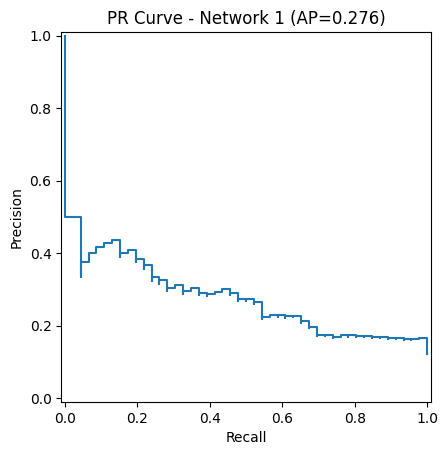

Network 1: AP=0.2756, E=46, P46=0.304, P50=0.300, P100=0.250


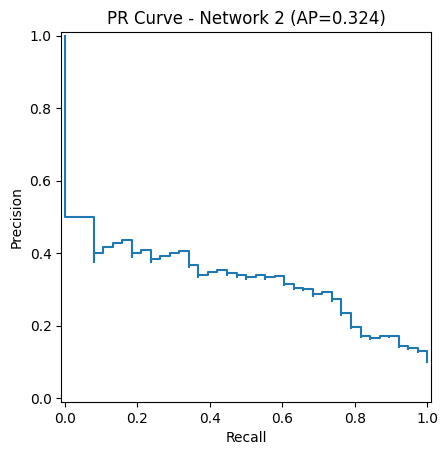

Network 2: AP=0.3240, E=38, P38=0.368, P50=0.340, P100=0.280


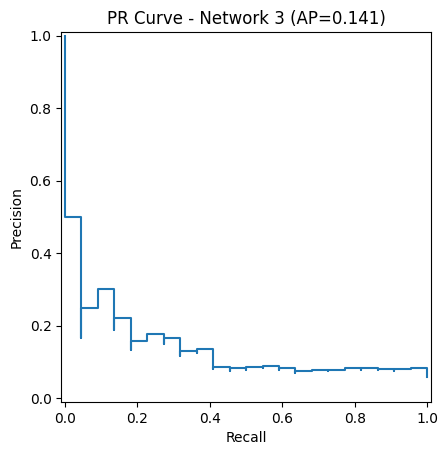

Network 3: AP=0.1408, E=22, P22=0.182, P50=0.140, P100=0.090


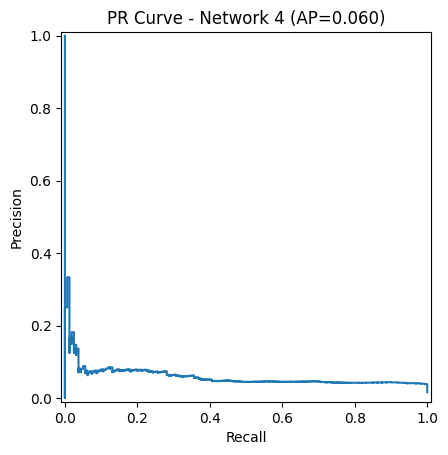

Network 4: AP=0.0599, E=160, P160=0.069, P50=0.120, P100=0.080


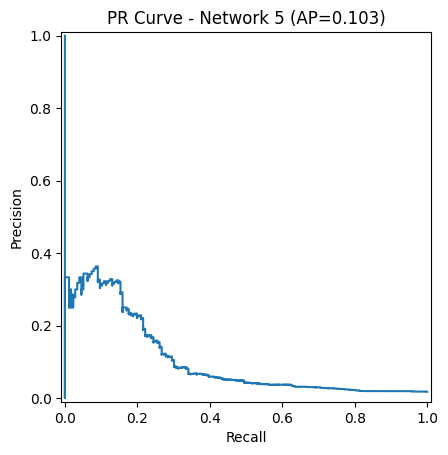

Network 5: AP=0.1032, E=176, P176=0.216, P50=0.320, P100=0.280


In [10]:
results = []
for graph in range(1,6):
    df = pd.read_csv(f'data_train/data{graph}.csv')
    target = pd.read_csv(f'data_train/target{graph}.csv')
    df_proc = impute_missing_random(df.copy())
    df_proc = pd.DataFrame(StandardScaler().fit_transform(df_proc), columns=df_proc.columns)
    corr_mat = abs_correlation_matrix(df_proc)
    pairs = [(a,b) for a in df_proc.columns for b in df_proc.columns if a!=b]
    true_edges = set([tuple(x) for x in target[['Cause','Effect']].values])
    y_true = np.array([1 if (a,b) in true_edges else 0 for a,b in pairs])  #Mapping des vraies paires
    y_score = np.array([corr_mat.loc[a,b] for a,b in pairs])
    pm = average_precision_score(y_true, y_score)
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    disp = PrecisionRecallDisplay(precision=precision, recall=recall)
    disp.plot()
    plt.title(f"PR Curve - Network {graph} (AP={pm:.3f})")
    plt.savefig(f"pr_corr_network{graph}.png", dpi=150)
    plt.show()

    order = np.argsort(y_score)[::-1]
    E = int(y_true.sum())
    ks = [E, 50, 100]
    precs = {}
    for k in ks:
        if k <= 0 or k > len(y_true):
            precs[f'P{k}'] = np.nan
        else:
            precs[f'P{k}'] = float(y_true[order[:k]].mean()) #Precision sur les k prémieres plus forte corrélation
    results.append({'graph':graph, 'PM':float(pm), 'E':E, **precs})
    print(f'Network {graph}: AP={pm:.4f}, E={E}, ' + ', '.join([f'{k}={v:.3f}' for k,v in precs.items()]))
# sauvegarder résumé
res_df = pd.DataFrame(results)
res_df.to_csv('ex2_summary_precision.csv', index=False)

**Interpretation**

Les résultats obtenus montrent que la corrélation peut détecter certaines relations entre gènes, mais ses performances restent limitées pour l’inférence de réseaux causaux.


Sur les cinq réseaux analysés, seuls les deux premiers présentent des scores modérés (AP ≈ 0.27 et 0.33), indiquant que les interactions les plus fortement corrélées correspondent parfois à de vraies relations de régulation. Cela suggère que, dans des réseaux simples ou faiblement bruités, la corrélation peut capturer des co‑expressions biologiquement pertinentes.
pour les réseaux 1 et 2, la courbe reste nettement au‑dessus de la ligne de base, montrant qu’il existe un compromis raisonnable entre précision et rappel lorsque l’on se limite aux interactions les plus fortement corrélées.

En revanche, les réseaux 3 et surtout 4 affichent des performances très faibles (AP ≈ 0.12 et 0.05). Dans ces cas, la corrélation devient presque incapable de distinguer les vraies interactions des faux positifs. Cela reflète les limites structurelles de cette approche : la corrélation est symétrique, ne capture pas la causalité  et est très sensible au bruit. Les courbes PR de ces réseaux sont presque plates, avec des valeurs de précision systématiquement inférieures à 0.2, ce qui montre qu’il n’existe pratiquement aucun compromis utile entre précision et rappel.

Le cinquième réseau présente des performances intermédiaires (AP généralement autour de 0.10 et 0.20), ce qui le place entre les réseaux faciles (1 et 2) et les réseaux difficiles (3 et 4). Cela suggère une structure plus bruitée que les deux premiers réseaux, mais moins extrême que le réseau 4.

De plus, la précision décroît systématiquement lorsque k augmente (P50 > P100), ce qui montre que seules les interactions les plus fortement corrélées sont informatives, tandis que les prédictions de rang inférieur sont dominées par le bruit.

Globalement, aucun réseau n’atteint une précision ou un AP supérieur à 0.5, ce qui est cohérent avec les limites intrinsèques de la corrélation pour l’inférence de réseaux orientés. Ces résultats confirment que la corrélation peut servir d’indicateur préliminaire de co‑expression, mais qu’elle est insuffisante pour reconstruire des réseaux causaux complexes.

# **Exercice3**


--- Network 1 ARACNE ---
Seuil MI (quantile 90%) pour réseau 1 : 0.6730


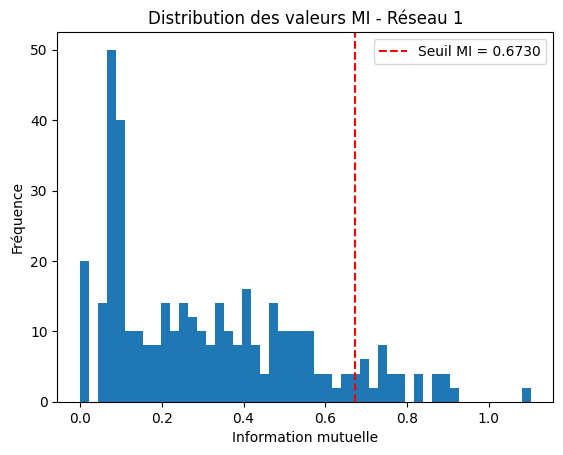

Liens supprimés par DPI : 8
lien suprimeés par DPI:[('V2', 'V3'), ('V2', 'V9'), ('V3', 'V9'), ('V3', 'V7'), ('V3', 'V8'), ('V7', 'V8'), ('V7', 'V13'), ('V6', 'V13')]
Wrote predictions_aracne_network1.csv


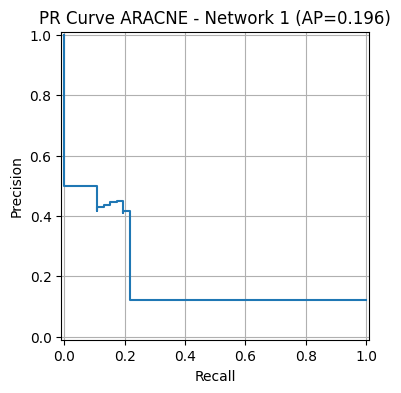


Résumé ARACNE :
 graph       AP  removed  threshold
     1 0.196415        8   0.673024


In [11]:
#1- Information mutuelle 
def mutual_information(x, y, bins=10):
    c_xy = np.histogram2d(x, y, bins=bins)[0]
    return mutual_info_score(None, None, contingency=c_xy)

def mutual_info_matrix(df, bins=10):
    cols = df.columns
    M = pd.DataFrame(0.0, index=cols, columns=cols)
    for i, a in enumerate(cols):
        for j, b in enumerate(cols):
            if j <= i:
                continue
            val = mutual_information(df[a], df[b], bins=bins)
            M.loc[a, b] = val
            M.loc[b, a] = val
    return M

# seuillage MI pour ne garder que les liens forts 
def threshold_mi(M, quantile=90):
    thr = np.percentile(M.values, quantile)
    M_thr = M.copy()
    M_thr[M_thr < thr] = 0.0
    return M_thr, thr

# 2- ARACNE avec DPI 
def aracne_dpi(M, eps=1e-6):
    M = M.copy()
    cols = list(M.columns)
    removed = []
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            for k in range(j+1, len(cols)):
                X, Y, Z = cols[i], cols[j], cols[k]

                Ixy = M.loc[X, Y]
                Ixz = M.loc[X, Z]
                Iyz = M.loc[Y, Z]

                if Ixy == 0 or Ixz == 0 or Iyz == 0:
                    continue

                # DPI condition
                if Ixy <= min(Ixz, Iyz) - eps:
                    removed.append((X, Y))
                    M.loc[X, Y] = M.loc[Y, X] = 0

                elif Ixz <= min(Ixy, Iyz) - eps:
                    removed.append((X, Z))
                    M.loc[X, Z] = M.loc[Z, X] = 0

                elif Iyz <= min(Ixy, Ixz) - eps:
                    removed.append((Y, Z))
                    M.loc[Y, Z] = M.loc[Z, Y] = 0

    return M, removed

aracne_summary = []

for graph in range(1, 2):
    print(f"\n--- Network {graph} ARACNE ---")
    # Chargement
    df = pd.read_csv(f"data_train/data{graph}.csv")
    # Imputation aléatoire
    df_imp = impute_missing_random(df)
    # Standardisation
    df_proc = pd.DataFrame(
        StandardScaler().fit_transform(df_imp),
        columns=df_imp.columns
    )
    # Matrice MI
    M = mutual_info_matrix(df_proc, bins=10)
    # Seuillage MI
    M_thr, thr = threshold_mi(M, quantile=90)
    print(f"Seuil MI (quantile 90%) pour réseau {graph} : {thr:.4f}")
    plt.hist(M.values.flatten(), bins=50)
    plt.axvline(thr, color='red', linestyle='--', label=f"Seuil MI = {thr:.4f}")
    plt.title(f"Distribution des valeurs MI - Réseau {graph}")
    plt.xlabel("Information mutuelle")
    plt.ylabel("Fréquence")
    plt.legend()
    plt.show()
    # ARACNE 
    M_aracne, removed = aracne_dpi(M_thr)
    print(f"Liens supprimés par DPI : {len(removed)}")

    #3-Affichage des liens supprimés
    print(f"lien suprimeés par DPI:{[link for link in removed]}")
    # Construction des scores prédits
    rows = []
    for a in M_aracne.index:
        for b in M_aracne.columns:
            if a == b:
                continue
            score = float(M_aracne.loc[a, b])
            rows.append((a, b, score))
    pred_aracne = pd.DataFrame(rows, columns=["Cause", "Effect", "Score"])
    pred_aracne["abs_score"] = pred_aracne["Score"].abs()
    pred_aracne = pred_aracne.sort_values("abs_score", ascending=False).drop(columns=["abs_score"])
    out_aracne = f"predictions_aracne_network{graph}.csv"
    pred_aracne.to_csv(out_aracne, index=False)
    print("Wrote", out_aracne)
    # Vérité terrain
    target = pd.read_csv(f"data_train/target{graph}.csv")
    true_edges = set([tuple(x) for x in target[["Cause", "Effect"]].values])
    pairs = [(a, b) for a in M_aracne.index for b in M_aracne.columns if a != b]
    y_true = np.array([1 if (a, b) in true_edges else 0 for a, b in pairs])
    y_score = np.array([float(M_aracne.loc[a, b]) for a, b in pairs])
    

    # 5- PR + AP
    ap = average_precision_score(y_true, y_score)
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    fig, ax = plt.subplots(figsize=(6, 4))
    disp = PrecisionRecallDisplay(precision=precision, recall=recall)
    disp.plot(ax=ax)
    ax.set_title(f"PR Curve ARACNE - Network {graph} (AP={ap:.3f})")
    ax.grid(True)
    plt.show(fig)
    aracne_summary.append(
        {"graph": graph, "AP": float(ap), "removed": len(removed), "threshold": float(thr)}
    )
# Résumé global
summary_df = pd.DataFrame(aracne_summary)
print("\nRésumé ARACNE :")
print(summary_df.to_string(index=False))


In [12]:
print("Valeurs MI des liens supprimés :")
for (a, b) in removed:
    print(a, b, "MI =", M.loc[a, b])


Valeurs MI des liens supprimés :
V2 V3 MI = 0.8602797630043356
V2 V9 MI = 0.7048367070290433
V3 V9 MI = 0.7043116566926015
V3 V7 MI = 0.7581768206822728
V3 V8 MI = 0.6842703727501642
V7 V8 MI = 0.7790355845031314
V7 V13 MI = 0.7377541493430146
V6 V13 MI = 0.7546226516375648


**Réponses à la question 4**

**La suppression de ces liens est cohérente, car dans chaque triplet ARACNE compare les trois valeurs d’information mutuelle et supprime systématiquement l’arête présentant la MI la plus faible. Même si les liens supprimés ont des valeurs élevées en absolu (souvent > 0.7), ils restent les plus faibles parmi les trois liens du triplet. Ils sont donc considérés comme des interactions indirectes selon le principe du DPI.**